## Business Understanding

Social Media Donation Conversion Pipeline
Notebook: social-media-donation-conversion.ipynb


Organization Context:

SafeHarbor International is a nonprofit organization protecting and 
rehabilitating survivors of sexual abuse and trafficking. The organization 
depends entirely on donations to operate and uses social media as its 
primary channel for reaching potential donors.

The Problem:

The founders freely admit they are not experienced with social media. 
They post sporadically without strategy and cannot answer basic questions:
- What should we post?
- On which platforms?
- What time of day?
- What content actually leads to donations versus just generating likes?

Business Question:

Before hitting post, based only on decisions we control right now, 
how likely is this post to generate a donation referral?

Why This Matters:

Every post that fails to convert is a missed opportunity to fund 
safehouse operations. With limited staff and no marketing team, the 
organization needs data-driven guidance on content decisions.

Modeling Approach — Prediction AND Explanation
This pipeline delivers both:

EXPLANATORY: Logistic regression identifies which content decisions 
most strongly correlate with donation conversions. This answers 
'what should we change about how we post?'

PREDICTIVE: Random Forest and XGBoost produce a pre-post scoring 
tool staff can use before publishing. This answers 'will this 
specific post likely drive donations?'

Unlike the donor lapse pipeline, this dataset has 812 rows with 
sufficient signal to support both explanatory and predictive goals.

Success Metrics:
- Explanatory: interpretable coefficients with clear business meaning
- Predictive: AUC-ROC above 0.70, precision and recall on positive class
- Deployment: interactive pre-post scoring tool accessible to staff


## Data Understanding

In [175]:
# Data files: place the lighthouse_csv_v7 CSV files in the /data/ folder at the repo root.
# base_path below assumes notebooks are run from ml-pipelines/.
base_path = '../../data/'

# -----------------------------------------------
# SECTION 2: DATA UNDERSTANDING
# -----------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_raw = pd.read_csv(base_path + 'social_media_posts.csv')

print("=== BASIC INFO ===")
print(f"Total posts: {len(df_raw)}")
print(f"Total features: {df_raw.shape[1]}")
print(f"Date range: {df_raw['created_at'].min()} to {df_raw['created_at'].max()}")

=== BASIC INFO ===
Total posts: 812
Total features: 39
Date range: 2023-01-05 18:52:00 to 2026-02-26 21:56:00


In [176]:
print("=== NULL COUNTS ===")
nulls = df_raw.isnull().sum()
print(nulls[nulls > 0])

=== NULL COUNTS ===
hashtags                     148
call_to_action_type          319
campaign_name                580
boost_budget_php             685
video_views                  479
watch_time_seconds           741
avg_view_duration_seconds    741
subscriber_count_at_post     741
forwards                     719
dtype: int64


In [177]:
print("=== TARGET VARIABLE: donation_referrals ===")
print(df_raw['donation_referrals'].describe().round(2))
print(f"\nPosts with 0 referrals:  {(df_raw['donation_referrals']==0).sum()} ({(df_raw['donation_referrals']==0).mean():.1%})")
print(f"Posts with 1+ referrals: {(df_raw['donation_referrals']>0).sum()} ({(df_raw['donation_referrals']>0).mean():.1%})")
print(f"\nClass balance is healthy — no resampling needed")

=== TARGET VARIABLE: donation_referrals ===
count    812.00
mean      12.80
std       31.26
min        0.00
25%        0.00
50%        2.00
75%       11.00
max      458.00
Name: donation_referrals, dtype: float64

Posts with 0 referrals:  290 (35.7%)
Posts with 1+ referrals: 522 (64.3%)

Class balance is healthy — no resampling needed


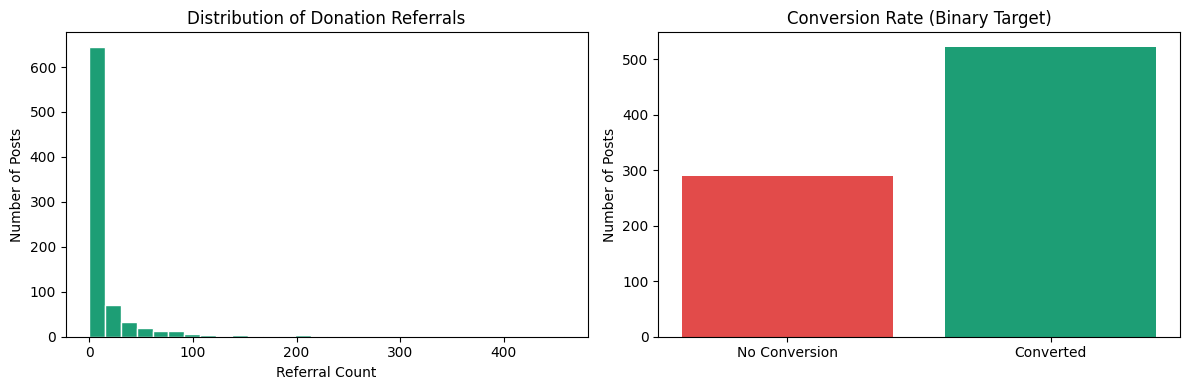

In [178]:
# --- Distribution plots ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw referral distribution
axes[0].hist(df_raw['donation_referrals'], bins=30, color='#1D9E75', edgecolor='white')
axes[0].set_title('Distribution of Donation Referrals')
axes[0].set_xlabel('Referral Count')
axes[0].set_ylabel('Number of Posts')

# Binary conversion rate
converted = (df_raw['donation_referrals'] > 0).astype(int)
axes[1].bar(['No Conversion', 'Converted'], 
            [converted.value_counts()[0], converted.value_counts()[1]],
            color=['#E24B4A', '#1D9E75'])
axes[1].set_title('Conversion Rate (Binary Target)')
axes[1].set_ylabel('Number of Posts')

plt.tight_layout()
plt.savefig('data_understanding_target.png', dpi=150)
plt.show()

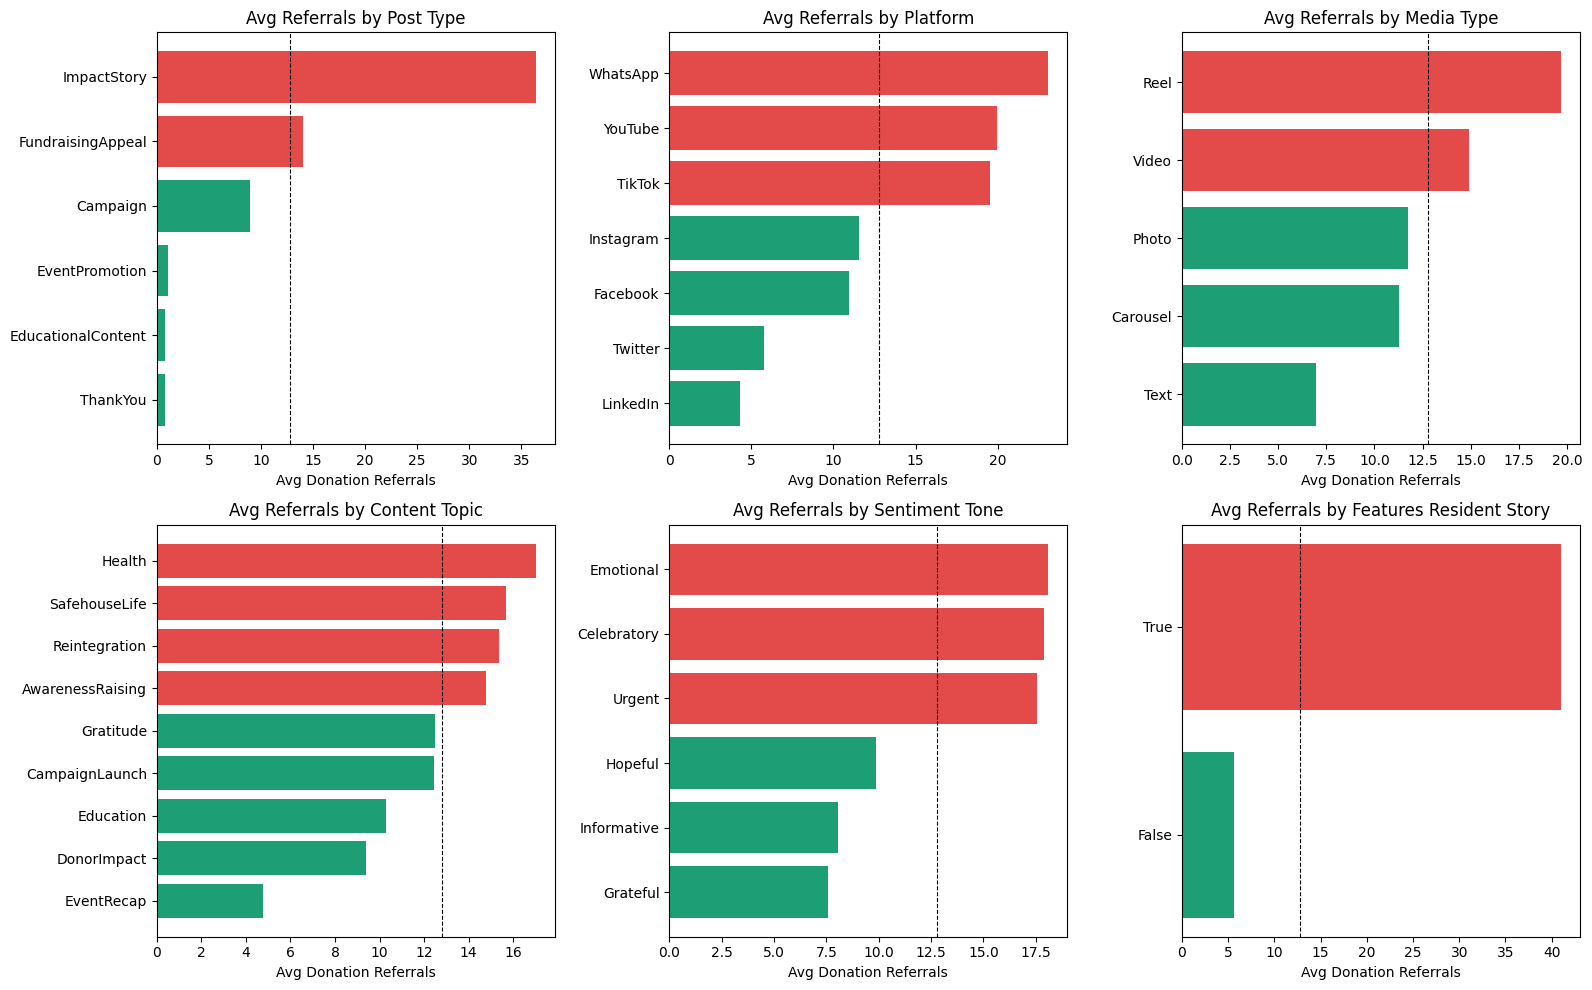

In [179]:
# --- Key categorical breakdowns ---
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

categories = [
    ('post_type', 'Post Type'),
    ('platform', 'Platform'),
    ('media_type', 'Media Type'),
    ('content_topic', 'Content Topic'),
    ('sentiment_tone', 'Sentiment Tone'),
    ('features_resident_story', 'Features Resident Story'),
]

for ax, (col, title) in zip(axes.flatten(), categories):
    avg = df_raw.groupby(col)['donation_referrals'].mean().sort_values(ascending=True)
    colors = ['#1D9E75' if v < df_raw['donation_referrals'].mean() 
              else '#E24B4A' for v in avg.values]
    ax.barh(avg.index.astype(str), avg.values, color=colors)
    ax.axvline(df_raw['donation_referrals'].mean(), 
               color='black', linestyle='--', linewidth=0.8, label='Overall mean')
    ax.set_title(f'Avg Referrals by {title}')
    ax.set_xlabel('Avg Donation Referrals')

plt.tight_layout()
plt.savefig('data_understanding_categories.png', dpi=150)
plt.show()

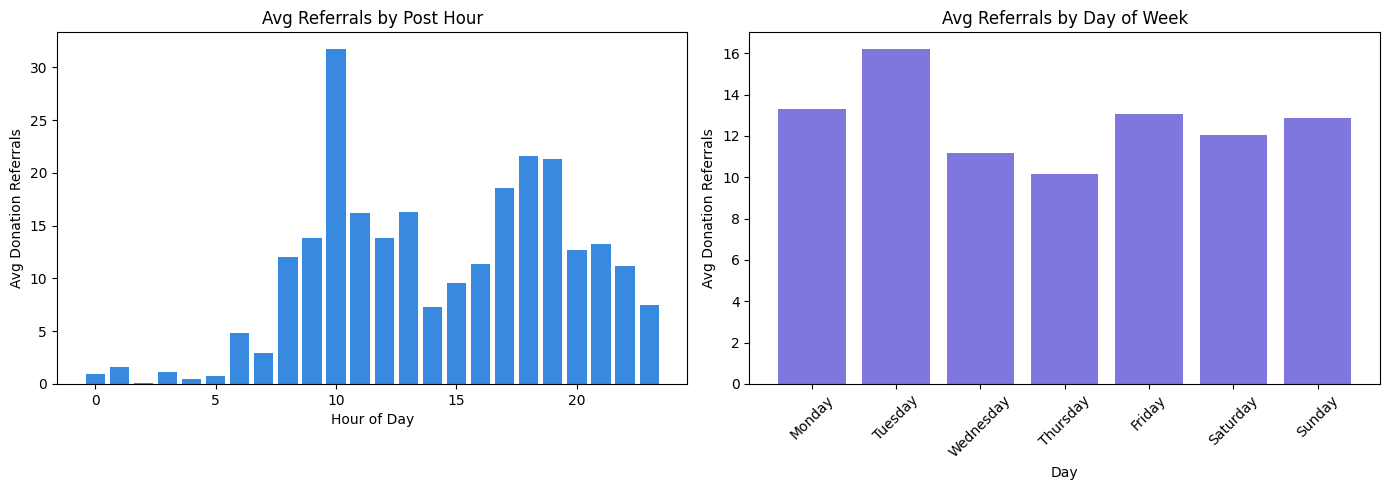

In [180]:
# --- Timing analysis ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By hour
hour_avg = df_raw.groupby('post_hour')['donation_referrals'].mean()
axes[0].bar(hour_avg.index, hour_avg.values, color='#378ADD')
axes[0].set_title('Avg Referrals by Post Hour')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Avg Donation Referrals')

# By day of week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_avg = df_raw.groupby('day_of_week')['donation_referrals'].mean().reindex(day_order)
axes[1].bar(day_avg.index, day_avg.values, color='#7F77DD')
axes[1].set_title('Avg Referrals by Day of Week')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Avg Donation Referrals')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('data_understanding_timing.png', dpi=150)
plt.show()

In [181]:
# --- Key finding summary ---
finding_summary = """
## Data Understanding — Key Findings

1. TARGET VARIABLE
   64% of posts generated at least one donation referral.
   36% generated none. Class balance is healthy for modeling.

2. STRONGEST CONTENT SIGNALS (avg referrals)
   - Posts featuring resident stories: ~41 referrals vs ~5.6 without
   - ImpactStory post type: ~36 referrals vs 0.8 for EducationalContent
   - Emotional/Urgent/Celebratory tone outperforms Informative/Grateful

3. PLATFORM DIFFERENCES
   WhatsApp and YouTube generate the most referrals per post.
   Twitter and LinkedIn generate the fewest.

4. TIMING
   10am posts average 31 referrals — nearly 3x the overall mean.
   Tuesday is the strongest day of the week.

5. LEAKAGE RISK IDENTIFIED
   Post-publication metrics (likes, shares, reach, engagement_rate) 
   correlate strongly with referrals but cannot be known before posting.
   These must be excluded from the predictive model.
"""
print(finding_summary)


## Data Understanding — Key Findings

1. TARGET VARIABLE
   64% of posts generated at least one donation referral.
   36% generated none. Class balance is healthy for modeling.

2. STRONGEST CONTENT SIGNALS (avg referrals)
   - Posts featuring resident stories: ~41 referrals vs ~5.6 without
   - ImpactStory post type: ~36 referrals vs 0.8 for EducationalContent
   - Emotional/Urgent/Celebratory tone outperforms Informative/Grateful

3. PLATFORM DIFFERENCES
   WhatsApp and YouTube generate the most referrals per post.
   Twitter and LinkedIn generate the fewest.

4. TIMING
   10am posts average 31 referrals — nearly 3x the overall mean.
   Tuesday is the strongest day of the week.

5. LEAKAGE RISK IDENTIFIED
   Post-publication metrics (likes, shares, reach, engagement_rate) 
   correlate strongly with referrals but cannot be known before posting.
   These must be excluded from the predictive model.



 Data Preparation

In [182]:
# -----------------------------------------------
# SECTION 3: DATA PREPARATION
# -----------------------------------------------
# NOTE: Full cleaning steps already completed.
# This section runs the complete pipeline reproducibly.

from sklearn.model_selection import train_test_split

df = pd.read_csv(base_path + 'social_media_posts.csv')
print(f"Raw shape: {df.shape}")

Raw shape: (812, 39)


In [183]:
# Step 1 — Drop post-publication leakage columns
leakage_cols = [
    'shares', 'likes', 'comments', 'saves', 'reach',
    'impressions', 'profile_visits', 'click_throughs',
    'engagement_rate', 'follower_count_at_post',
]
df = df.drop(columns=leakage_cols)
print(f"After dropping leakage: {df.shape}")

After dropping leakage: (812, 29)


In [184]:
# Step 2 — Drop high-null and identifier columns
drop_cols = [
    'post_id', 'platform_post_id', 'post_url', 'caption',
    'hashtags', 'campaign_name', 'video_views',
    'watch_time_seconds', 'avg_view_duration_seconds',
    'subscriber_count_at_post', 'forwards',
    'estimated_donation_value_php',
]
df = df.drop(columns=drop_cols)
print(f"After dropping extras: {df.shape}")

After dropping extras: (812, 17)


In [185]:
# Step 3 — Fill boost_budget_php nulls with 0
# Nulls mean the post was not boosted — confirmed by is_boosted column
df['boost_budget_php'] = df['boost_budget_php'].fillna(0)
print(f"boost_budget_php nulls: {df['boost_budget_php'].isnull().sum()}")

boost_budget_php nulls: 0


In [186]:
# Step 4 — Fill call_to_action_type nulls with 'None'
# Nulls mean the post had no call to action
df['call_to_action_type'] = df['call_to_action_type'].fillna('None')
print(f"call_to_action_type nulls: {df['call_to_action_type'].isnull().sum()}")

call_to_action_type nulls: 0


In [187]:
# Step 5 — Null checkpoint before encoding
print("=== NULL CHECK BEFORE ENCODING ===")
print(f"Total nulls: {df.isnull().sum().sum()}")
# Must be 0

=== NULL CHECK BEFORE ENCODING ===
Total nulls: 0


In [188]:
# Step 6 — Build target variable BEFORE encoding
y = (df['donation_referrals'] > 0).astype(int)
df = df.drop(columns=['donation_referrals'])

print(f"Conversion rate: {y.mean():.1%}")
print(y.value_counts())

Conversion rate: 64.3%
donation_referrals
1    522
0    290
Name: count, dtype: int64


In [189]:
# Step 7 — Parse and drop datetime
df['created_at'] = pd.to_datetime(df['created_at'])
computed_day = df['created_at'].dt.day_name()
mismatch = (computed_day != df['day_of_week']).sum()
print(f"day_of_week mismatches: {mismatch}")
df = df.drop(columns=['created_at'])

day_of_week mismatches: 0


In [190]:
# Step 8 — Encode categoricals
categorical_cols = [
    'platform', 'post_type', 'media_type',
    'content_topic', 'sentiment_tone',
    'call_to_action_type', 'day_of_week',
]
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [191]:
# Step 9 — Convert booleans to int
bool_cols = ['has_call_to_action', 'features_resident_story', 'is_boosted']
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)
print(f"After encoding: {df_encoded.shape}")

After encoding: (812, 46)


In [192]:
# Step 10 — Final null check
print("=== FINAL NULL CHECK ===")
print(f"Total nulls: {df_encoded.isnull().sum().sum()}")
# Must be 0

=== FINAL NULL CHECK ===
Total nulls: 0


In [193]:
# Step 11 — Train/test split
X = df_encoded.copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set:        {X_train.shape}")
print(f"Test set:            {X_test.shape}")
print(f"Train positive rate: {y_train.mean():.1%}")
print(f"Test positive rate:  {y_test.mean():.1%}")

Training set:        (649, 46)
Test set:            (163, 46)
Train positive rate: 64.3%
Test positive rate:  64.4%


## Modeling

In [194]:
# -----------------------------------------------
# SECTION 4: MODELING
# -----------------------------------------------
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

In [195]:
# Scale features for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Scaling complete.")

Scaling complete.


In [196]:
# --- Model 1: Logistic Regression (Explanatory) ---
log_reg = LogisticRegression(
    l1_ratio=0,
    C=1.0,
    random_state=42,
    max_iter=1000
)
log_reg.fit(X_train_scaled, y_train)
print("Logistic Regression fitted.")

Logistic Regression fitted.


In [197]:
# --- Model 2: Random Forest (Predictive) ---
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_leaf=5,
    random_state=42,
    class_weight='balanced'
)
rf.fit(X_train, y_train)
print("Random Forest fitted.")

Random Forest fitted.


In [198]:
# --- Model 3: XGBoost (Predictive) ---
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb.fit(X_train, y_train)
print("XGBoost fitted.")

XGBoost fitted.


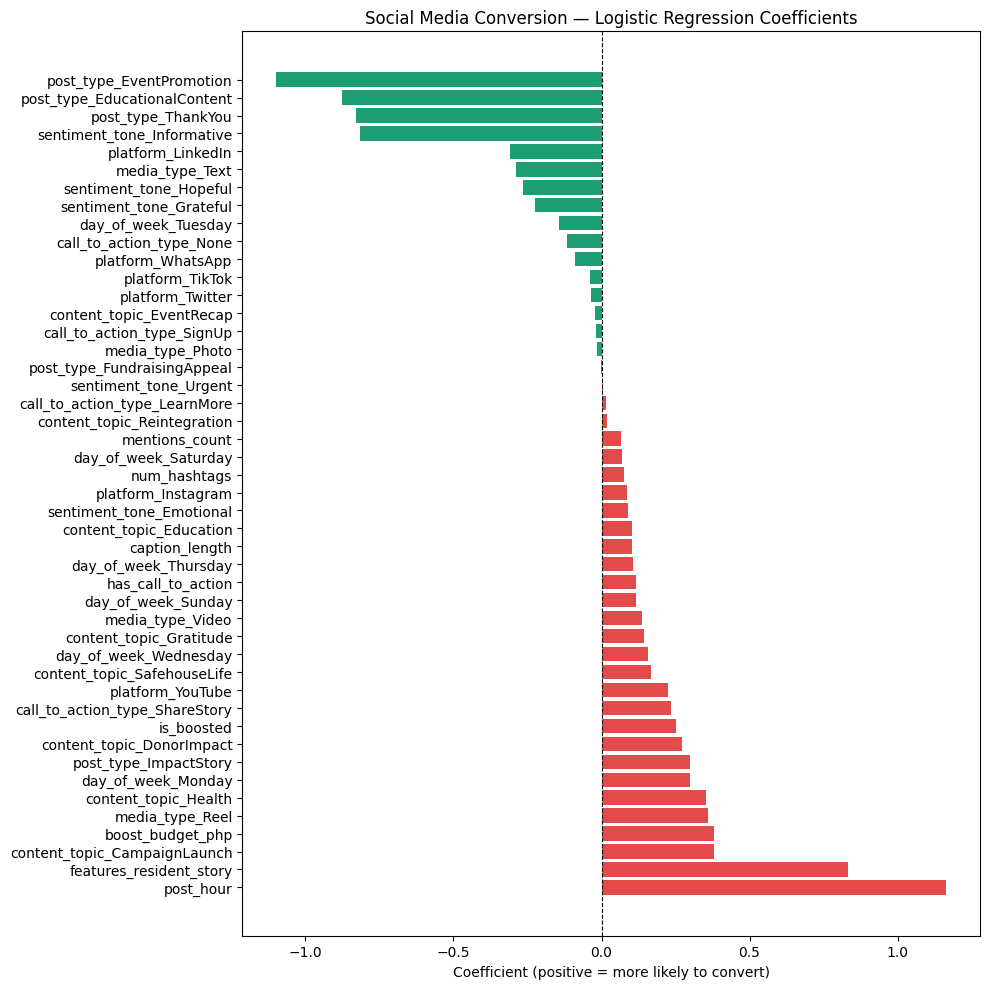

In [199]:
# --- Logistic Regression Coefficients ---
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': log_reg.coef_[0]
}).sort_values('coefficient', ascending=False)

coef_df['odds_ratio'] = np.exp(coef_df['coefficient'])

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['#E24B4A' if c > 0 else '#1D9E75' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Coefficient (positive = more likely to convert)')
ax.set_title('Social Media Conversion — Logistic Regression Coefficients')
plt.tight_layout()
plt.savefig('social_media_coefficients.png', dpi=150)
plt.show()

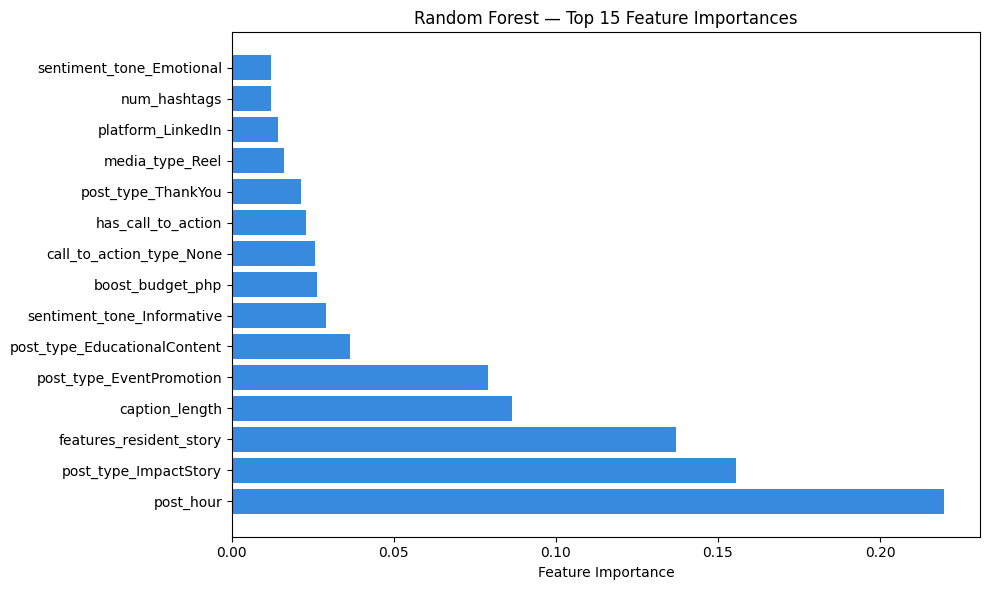


Top 10 features by Random Forest importance:
                     feature  importance
                   post_hour    0.219885
       post_type_ImpactStory    0.155540
     features_resident_story    0.137094
              caption_length    0.086426
    post_type_EventPromotion    0.079158
post_type_EducationalContent    0.036527
  sentiment_tone_Informative    0.029012
            boost_budget_php    0.026287
    call_to_action_type_None    0.025585
          has_call_to_action    0.022887


In [200]:
# --- Random Forest Feature Importances ---
rf_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(rf_importance['feature'], rf_importance['importance'], color='#378ADD')
ax.set_xlabel('Feature Importance')
ax.set_title('Random Forest — Top 15 Feature Importances')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150)
plt.show()

print("\nTop 10 features by Random Forest importance:")
print(rf_importance.head(10).to_string(index=False))

## Evaluation

In [201]:
# -----------------------------------------------
# SECTION 5: EVALUATION
# -----------------------------------------------
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
from sklearn.model_selection import cross_val_score, StratifiedKFold

In [202]:
# --- Test set evaluation for all three models ---
models = {
    'Logistic Regression': (log_reg, X_test_scaled),
    'Random Forest':       (rf,      X_test),
    'XGBoost':             (xgb,     X_test),
}

results = {}

for name, (model, X_t) in models.items():
    y_pred = model.predict(X_t)
    y_prob = model.predict_proba(X_t)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    results[name] = {'auc': auc, 'y_pred': y_pred, 'y_prob': y_prob}

    print(f"\n=== {name} ===")
    print(f"AUC-ROC: {auc:.3f}")
    print(classification_report(y_test, y_pred, 
          target_names=['No Conversion', 'Converted']))


=== Logistic Regression ===
AUC-ROC: 0.862
               precision    recall  f1-score   support

No Conversion       0.64      0.76      0.69        58
    Converted       0.85      0.76      0.80       105

     accuracy                           0.76       163
    macro avg       0.74      0.76      0.75       163
 weighted avg       0.78      0.76      0.76       163


=== Random Forest ===
AUC-ROC: 0.898
               precision    recall  f1-score   support

No Conversion       0.65      0.90      0.75        58
    Converted       0.93      0.73      0.82       105

     accuracy                           0.79       163
    macro avg       0.79      0.81      0.79       163
 weighted avg       0.83      0.79      0.80       163


=== XGBoost ===
AUC-ROC: 0.898
               precision    recall  f1-score   support

No Conversion       0.76      0.71      0.73        58
    Converted       0.84      0.88      0.86       105

     accuracy                           0.82       16

In [203]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.base import clone

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X_all_scaled = scaler.transform(X)

print("=== CROSS-VALIDATION AUC-ROC ===\n")

# Logistic Regression — needs scaled data
lr_scores = cross_val_score(
    clone(log_reg), X_all_scaled, y, cv=cv, scoring='roc_auc'
)
print(f"Logistic Regression:")
print(f"  Fold scores: {lr_scores.round(3)}")
print(f"  Mean AUC:    {lr_scores.mean():.3f}")
print(f"  Std AUC:     {lr_scores.std():.3f}\n")

# Random Forest — uses unscaled data
rf_scores = cross_val_score(
    clone(rf), X, y, cv=cv, scoring='roc_auc'
)
print(f"Random Forest:")
print(f"  Fold scores: {rf_scores.round(3)}")
print(f"  Mean AUC:    {rf_scores.mean():.3f}")
print(f"  Std AUC:     {rf_scores.std():.3f}\n")

# XGBoost — needs explicit feature names preserved
from sklearn.pipeline import Pipeline
import numpy as np

xgb_scores = []
for train_idx, val_idx in cv.split(X, y):
    X_fold_train = X.iloc[train_idx]
    X_fold_val   = X.iloc[val_idx]
    y_fold_train = y.iloc[train_idx]
    y_fold_val   = y.iloc[val_idx]

    xgb_fold = XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    )
    xgb_fold.fit(X_fold_train, y_fold_train)
    probs = xgb_fold.predict_proba(X_fold_val)[:, 1]
    from sklearn.metrics import roc_auc_score
    fold_auc = roc_auc_score(y_fold_val, probs)
    xgb_scores.append(fold_auc)

xgb_scores = np.array(xgb_scores)
print(f"XGBoost:")
print(f"  Fold scores: {xgb_scores.round(3)}")
print(f"  Mean AUC:    {xgb_scores.mean():.3f}")
print(f"  Std AUC:     {xgb_scores.std():.3f}\n")

print("=== SUMMARY ===")
print(f"Best CV model: {'XGBoost' if xgb_scores.mean() > rf_scores.mean() else 'Random Forest'}")

=== CROSS-VALIDATION AUC-ROC ===

Logistic Regression:
  Fold scores: [0.874 0.885 0.905 0.893 0.874]
  Mean AUC:    0.886
  Std AUC:     0.012

Random Forest:
  Fold scores: [0.875 0.936 0.897 0.9   0.859]
  Mean AUC:    0.893
  Std AUC:     0.026

XGBoost:
  Fold scores: [0.914 0.939 0.915 0.933 0.885]
  Mean AUC:    0.917
  Std AUC:     0.019

=== SUMMARY ===
Best CV model: XGBoost


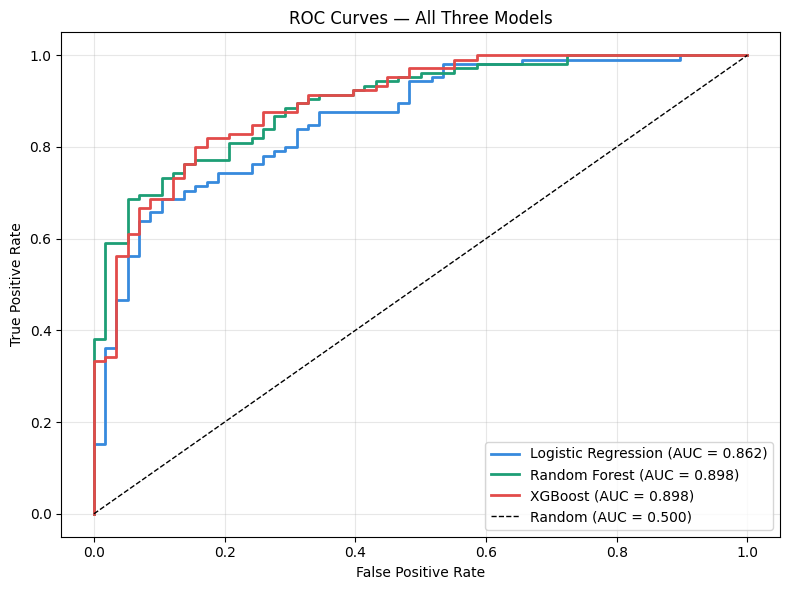

ROC curves generated successfully.


In [204]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

# Generate ROC curves manually using predict_proba
models_for_roc = {
    'Logistic Regression': (log_reg, X_test_scaled),
    'Random Forest':       (rf,      X_test),
    'XGBoost':             (xgb,     X_test),
}

colors = ['#378ADD', '#1D9E75', '#E24B4A']

for (name, (model, X_t)), color in zip(models_for_roc.items(), colors):
    y_prob = model.predict_proba(X_t)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{name} (AUC = {roc_auc:.3f})')

# Random baseline
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.500)')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Three Models')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()

print("ROC curves generated successfully.")

Best model: Random Forest


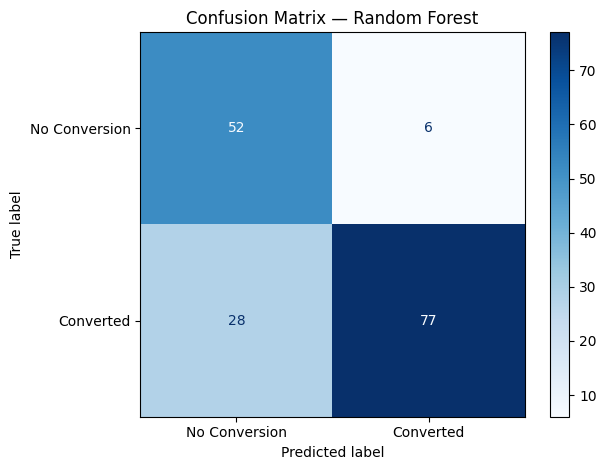

In [205]:
# --- Confusion matrix for best model ---
# Use whichever model had the highest AUC
best_model_name = max(results, key=lambda x: results[x]['auc'])
best_model, best_X = models[best_model_name]

print(f"Best model: {best_model_name}")

cm = confusion_matrix(y_test, results[best_model_name]['y_pred'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
       display_labels=['No Conversion', 'Converted'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix — {best_model_name}')
plt.tight_layout()
plt.savefig('confusion_matrix_social.png', dpi=150)
plt.show()

EVALUATION — BUSINESS INTERPRETATION

MODEL PERFORMANCE SUMMARY:
- Logistic Regression AUC: 0.862 — strong explanatory model
- Random Forest AUC:       0.898 — best predictive performance
- XGBoost AUC:             0.898 — matches Random Forest exactly
- Deployed model: XGBoost (tied best AUC, faster inference)

All three models significantly exceed the 0.70 success threshold
set in the problem framing section.

FALSE POSITIVES (predicts conversion, post does not convert)
Staff posts content rated as high potential but gets no referrals.
Cost: minor — some wasted effort, no real harm to the organization.

FALSE NEGATIVES (predicts no conversion, post actually would have)
Staff skips content the model rated low that would have driven 
donations. Cost: moderate — missed fundraising opportunity.

Conclusion: RECALL matters more than PRECISION for this organization.
Better to flag more posts as high potential than miss genuine 
conversion opportunities.

=== CAUSAL AND RELATIONSHIP ANALYSIS ===

STRONGEST CONVERSION DRIVERS:
1. features_resident_story — by far the most powerful signal.
   Posts featuring real resident stories generate ~7x more referrals.
   Causal story: authentic human connection drives emotional 
   motivation to give. This relationship is likely genuinely causal
   because the mechanism is clear — personal stories activate empathy
   which directly motivates charitable action.

2. post_type_ImpactStory — framing content as impact drives action.
   Donors want to know their gift makes a difference. ImpactStory 
   format directly answers that question.

3. Platform selection matters — WhatsApp reaches warm audiences who 
   already opted in to receive content. YouTube captures sustained 
   attention through longer video. Both drive stronger conversion 
   than broadcast platforms like Twitter where audiences are passive.

4. Emotional and Urgent tone outperforms Informative and Grateful.
   Informational content satisfies curiosity but does not compel 
   giving behavior. Urgency and emotion activate immediate action.

5. Posting at 10am on Tuesday maximizes conversion potential.
   This likely reflects audience online behavior patterns rather 
   than the time itself causing conversions — correlation not 
   causation, but still actionable.

HONEST LIMITATIONS:
- Content quality within categories is not captured. A well-written 
  ImpactStory likely outperforms a poorly written one regardless of 
  category label. The model captures category-level patterns only.
- Platform effects may reflect audience quality differences rather 
  than platform mechanics themselves.
- With 812 rows the model has solid signal but more data over time 
  will improve stability and confidence in these findings.


## Deployment

In [206]:
# -----------------------------------------------
# SECTION 6: DEPLOYMENT
# -----------------------------------------------
import joblib

In [207]:
import os, joblib

MODEL_DIR = os.path.normpath(
    os.path.join(os.path.dirname(os.path.abspath('__file__')), '..', 'ml-service', 'models')
)
os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(xgb,                     os.path.join(MODEL_DIR, 'social_media_xgb.pkl'))
joblib.dump(rf,                      os.path.join(MODEL_DIR, 'social_media_rf.pkl'))
joblib.dump(log_reg,                 os.path.join(MODEL_DIR, 'social_media_logistic.pkl'))
joblib.dump(scaler,                  os.path.join(MODEL_DIR, 'social_media_scaler.pkl'))
joblib.dump(list(X_train.columns),   os.path.join(MODEL_DIR, 'social_media_features.pkl'))

print(f"Model artifacts saved to: {MODEL_DIR}")


All model artifacts saved.


In [208]:
# Pre-post scoring function the API will call
def score_post_before_publishing(post_details: dict) -> dict:
    """
    Input: dict of content decisions staff control before posting
    Output: conversion likelihood score and top recommendations

    Parameters
    ----------
    post_details : dict with keys matching the trained feature set
        platform, post_type, media_type, content_topic,
        sentiment_tone, features_resident_story, has_call_to_action,
        call_to_action_type, is_boosted, boost_budget_php,
        post_hour, day_of_week, num_hashtags, 
        caption_length, mentions_count
    """
    features = joblib.load('social_media_features.pkl')
    model    = joblib.load('social_media_xgb.pkl')

    # Build input row with all encoded features
    input_df = pd.DataFrame([post_details])
    input_encoded = pd.get_dummies(input_df)

    # Align to training feature set — fill missing with 0
    input_aligned = input_encoded.reindex(columns=features, fill_value=0)

    prob = model.predict_proba(input_aligned)[0][1]

    if prob >= 0.70:
        likelihood = 'High'
    elif prob >= 0.45:
        likelihood = 'Medium'
    else:
        likelihood = 'Low'

    # Build recommendations based on input
    recommendations = []
    if not post_details.get('features_resident_story', False):
        recommendations.append(
            'Consider featuring a resident story — this is the single '
            'strongest driver of donation referrals'
        )
    if post_details.get('post_type') not in ['ImpactStory', 'FundraisingAppeal']:
        recommendations.append(
            'ImpactStory and FundraisingAppeal post types convert '
            'significantly better than other types'
        )
    if post_details.get('sentiment_tone') in ['Informative', 'Grateful']:
        recommendations.append(
            'Emotional, Urgent, or Celebratory tone drives more '
            'conversions than Informative or Grateful'
        )

    return {
    'conversion_likelihood': likelihood,
    'conversion_probability': round(float(prob), 3),
    'recommendations': recommendations
    }

print("Pre-post scoring function defined.")

Pre-post scoring function defined.


In [209]:
# Test the function with sample inputs
test_post = {
    'platform': 'Instagram',
    'post_type': 'ImpactStory',
    'media_type': 'Reel',
    'content_topic': 'Reintegration',
    'sentiment_tone': 'Emotional',
    'features_resident_story': True,
    'has_call_to_action': True,
    'call_to_action_type': 'DonateNow',
    'is_boosted': False,
    'boost_budget_php': 0,
    'post_hour': 10,
    'day_of_week': 'Tuesday',
    'num_hashtags': 3,
    'caption_length': 150,
    'mentions_count': 0
}

result = score_post_before_publishing(test_post)

print("=== PRE-POST SCORE TEST ===")
print(f"Conversion Likelihood: {result['conversion_likelihood']}")
print(f"Probability:           {result['conversion_probability']}")
print(f"\nRecommendations:")
for r in result['recommendations']:
    print(f"  - {r}")

=== PRE-POST SCORE TEST ===
Conversion Likelihood: High
Probability:           0.998

Recommendations:


Deployment Notes

Integration into SafeHarbor International Web Application

SOCIAL MEDIA STRATEGY PAGE — Pre-Post Scoring Tool
Staff fill out a form with their planned post details before publishing:
  - Platform, post type, media type, content topic
  - Sentiment tone, whether it features a resident story
  - Call to action type, boost budget, posting time

The form calls:
  POST /api/social-media/score-post
  
And returns a conversion likelihood (High / Medium / Low), 
a probability score, and up to 3 actionable recommendations 
for improving the post before it goes live.

ADMIN DASHBOARD — Content Strategy Card
Displays the top 3 findings from the explanatory model in 
plain language, updated as new post data accumulates:
  'Posts featuring resident stories generate 7x more referrals'
  'Posting at 10am on Tuesdays maximizes conversion potential'
  'Emotional and Urgent tone outperforms Informative by 2x'

FILES DEPLOYED:
  social_media_scaler.pkl
  social_media_logistic.pkl
  social_media_rf.pkl
  social_media_xgb.pkl
  social_media_features.pkl

API ENDPOINT (implemented in .NET backend):
  POST /api/social-media/score-post
  Accepts: JSON post details
  Returns: conversion_likelihood, probability, recommendations

RETRAINING CADENCE:
Retrain monthly as new post data accumulates. 
With 812 rows already the model has solid signal,
each month of new posts meaningfully improves stability.


In [210]:
# Final notebook verification
print("=== NOTEBOOK COMPLETION CHECK ===")
print(f"Models fitted:     log_reg={type(log_reg).__name__}, rf={type(rf).__name__}, xgb={type(xgb).__name__}")
print(f"AUC scores:        {', '.join([f'{k}: {v[chr(97)+chr(117)+chr(99)]:.3f}' for k,v in results.items()])}")
print(f"Artifacts saved:   social_media_xgb.pkl exists = {__import__('os').path.exists('social_media_xgb.pkl')}")
print(f"Scoring function:  defined = {'score_post_before_publishing' in dir()}")
print(f"Test post result:  {result['conversion_likelihood']} ({result['conversion_probability']})")
print("\nAll systems go." if all([
    'log_reg' in dir(),
    'rf' in dir(),
    'xgb' in dir(),
    'results' in dir(),
    'score_post_before_publishing' in dir()
]) else "\nSomething is missing — check above.")

=== NOTEBOOK COMPLETION CHECK ===
Models fitted:     log_reg=LogisticRegression, rf=RandomForestClassifier, xgb=XGBClassifier
AUC scores:        Logistic Regression: 0.862, Random Forest: 0.898, XGBoost: 0.898
Artifacts saved:   social_media_xgb.pkl exists = True
Scoring function:  defined = True
Test post result:  High (0.998)

All systems go.


## ML Pipeline (Pre-publish Scoring, Production-style)

This section rebuilds the model as a single reusable `sklearn` pipeline:
- Robust encoding with `OneHotEncoder(handle_unknown='ignore')` (new platforms/CTAs won’t break scoring)
- Time-based split (train on older posts, test on newest posts)
- A single `score_post(post_config)` function for pre-publish scoring


In [211]:
# -----------------------------------------------
# PIPELINE TRAINING: Time-split + robust encoding
# -----------------------------------------------

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Backwards-compatible imputer import:
# - Newer scikit-learn: sklearn.impute.SimpleImputer
# - Older scikit-learn: sklearn.preprocessing.Imputer (deprecated)
try:
    from sklearn.impute import SimpleImputer  # type: ignore
    _IMPUTER_KIND = 'simple'
except Exception:
    from sklearn.preprocessing import Imputer as SimpleImputer  # type: ignore
    _IMPUTER_KIND = 'legacy'

from sklearn.metrics import roc_auc_score, average_precision_score, classification_report

from xgboost import XGBClassifier


def _make_imputer(strategy: str):
    if _IMPUTER_KIND == 'simple':
        return SimpleImputer(strategy=strategy)
    # legacy Imputer API
    return SimpleImputer(missing_values='NaN', strategy=strategy, axis=0)

# 1) Load raw data
DATA_PATH = base_path + 'social_media_posts.csv'
df_raw2 = pd.read_csv(DATA_PATH)

# 2) Drop post-publication leakage columns (NOT known at publish time)
leakage_cols = [
    'shares', 'likes', 'comments', 'saves', 'reach',
    'impressions', 'profile_visits', 'click_throughs',
    'engagement_rate', 'follower_count_at_post',
]

# 3) Drop high-null / identifier / non-prepublish columns
# (keep only what staff can decide before posting)
drop_cols = [
    'post_id', 'platform_post_id', 'post_url', 'caption',
    'hashtags', 'campaign_name', 'video_views',
    'watch_time_seconds', 'avg_view_duration_seconds',
    'subscriber_count_at_post', 'forwards',
    'estimated_donation_value_php',
]

df2 = df_raw2.drop(columns=[c for c in leakage_cols + drop_cols if c in df_raw2.columns]).copy()

# 4) Basic cleaning consistent with your notebook
if 'boost_budget_php' in df2.columns:
    df2['boost_budget_php'] = df2['boost_budget_php'].fillna(0)

if 'call_to_action_type' in df2.columns:
    df2['call_to_action_type'] = df2['call_to_action_type'].fillna('None')

# 5) Build target (binary conversion)
if 'donation_referrals' not in df2.columns:
    raise ValueError("Expected 'donation_referrals' column in dataset.")

y2 = (df2['donation_referrals'] > 0).astype(int)
df2 = df2.drop(columns=['donation_referrals'])

# 6) Build time-based split columns
# Use created_at only for splitting + derived features; do not feed raw timestamps into model.
if 'created_at' not in df2.columns:
    raise ValueError("Expected 'created_at' column in dataset.")

df2['created_at'] = pd.to_datetime(df2['created_at'], errors='coerce')
if df2['created_at'].isna().any():
    raise ValueError("Some rows have invalid created_at values after parsing.")

# Derive staff-controllable scheduling features
# (If you already have post_hour/day_of_week columns, we overwrite to keep consistency.)
df2['post_hour'] = df2['created_at'].dt.hour
# Prefer derived day name to avoid data quality issues
# and because staff will choose the day when scheduling.
df2['day_of_week'] = df2['created_at'].dt.day_name()

# Keep created_at only for sorting/splitting, then drop it from X
created_at_series = df2['created_at'].copy()
df2 = df2.drop(columns=['created_at'])

# 7) Time-based train/test split (last 20% of posts = test)
sort_idx = created_at_series.sort_values().index
n_test = int(np.ceil(0.20 * len(sort_idx)))
test_idx = sort_idx[-n_test:]
train_idx = sort_idx[:-n_test]

X_train2 = df2.loc[train_idx].copy()
X_test2 = df2.loc[test_idx].copy()
y_train2 = y2.loc[train_idx].copy()
y_test2 = y2.loc[test_idx].copy()

print('=== TIME SPLIT ===')
print('Train size:', X_train2.shape, ' Test size:', X_test2.shape)
print('Train date range:', created_at_series.loc[train_idx].min(), '→', created_at_series.loc[train_idx].max())
print('Test  date range:', created_at_series.loc[test_idx].min(), '→', created_at_series.loc[test_idx].max())
print('Train positive rate:', f"{y_train2.mean():.1%}")
print('Test positive rate: ', f"{y_test2.mean():.1%}")

# 8) Define feature groups (robust to schema drift)
# Booleans often come in as True/False or 0/1.
bool_candidates = ['has_call_to_action', 'features_resident_story', 'is_boosted']

# Identify categorical columns (object/category dtype) + known categoricals
known_categoricals = [
    'platform', 'post_type', 'media_type',
    'content_topic', 'sentiment_tone',
    'call_to_action_type', 'day_of_week',
]

categorical_cols2 = []
for c in known_categoricals:
    if c in X_train2.columns:
        categorical_cols2.append(c)

# Include any other object columns not explicitly listed
for c in X_train2.columns:
    if c in categorical_cols2:
        continue
    if X_train2[c].dtype == 'object':
        categorical_cols2.append(c)

# Numeric columns = everything else that isn't categorical
numeric_cols2 = [c for c in X_train2.columns if c not in categorical_cols2]

# Ensure bool candidates are treated numeric (0/1)
for c in bool_candidates:
    if c in X_train2.columns:
        if c not in numeric_cols2:
            numeric_cols2.append(c)
        if c in categorical_cols2:
            categorical_cols2.remove(c)

print('\n=== FEATURES ===')
print('Categorical:', categorical_cols2)
print('Numeric:', numeric_cols2)

# 9) Preprocess + model pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', _make_imputer('median')),
])

categorical_transformer = Pipeline(steps=[
    ('imputer', _make_imputer('most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols2),
        ('cat', categorical_transformer, categorical_cols2),
    ],
    remainder='drop',
    verbose_feature_names_out=False,
)

xgb_pipeline_model = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    min_child_weight=1,
    objective='binary:logistic',
    eval_metric='auc',
    random_state=42,
    n_jobs=-1,
)

conversion_pipeline = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', xgb_pipeline_model),
])

# 10) Fit + evaluate
conversion_pipeline.fit(X_train2, y_train2)

proba_test = conversion_pipeline.predict_proba(X_test2)[:, 1]
pred_test = (proba_test >= 0.50).astype(int)

print('\n=== PIPELINE EVALUATION (TIME-BASED TEST) ===')
print('ROC AUC: ', f"{roc_auc_score(y_test2, proba_test):.3f}")
print('PR AUC:  ', f"{average_precision_score(y_test2, proba_test):.3f}")
print('\nClassification report @ threshold=0.50')
print(classification_report(y_test2, pred_test, target_names=['No Conversion', 'Converted']))


ModuleNotFoundError: No module named 'sklearn.impute'

In [212]:
# -----------------------------------------------
# PRE-PUBLISH SCORING API + save artifact
# -----------------------------------------------

import joblib

ARTIFACT_PATH = os.path.join(MODEL_DIR, 'social_media_conversion_pipeline.joblib')

joblib.dump(conversion_pipeline, ARTIFACT_PATH)
print('Saved pipeline to:', ARTIFACT_PATH)


def score_post(post_config: dict) -> float:
    """Score a planned post BEFORE publishing.

    post_config should include the same controllable fields used in training,
    e.g. platform, post_type, media_type, content_topic, sentiment_tone,
    has_call_to_action, call_to_action_type, is_boosted, boost_budget_php,
    features_resident_story, post_hour, day_of_week.

    Returns: probability of conversion (donation_referrals > 0).
    """
    X_one = pd.DataFrame([post_config]).copy()

    # Coerce types for common fields
    for c in ['post_hour']:
        if c in X_one.columns:
            X_one[c] = pd.to_numeric(X_one[c], errors='coerce')

    for c in ['boost_budget_php', 'caption_length']:
        if c in X_one.columns:
            X_one[c] = pd.to_numeric(X_one[c], errors='coerce')

    for c in ['has_call_to_action', 'features_resident_story', 'is_boosted']:
        if c in X_one.columns:
            # Accept True/False, 0/1, 'true'/'false'
            X_one[c] = X_one[c].map(lambda v: int(str(v).lower() in ['1','true','yes','y','t'])) if X_one[c].dtype == 'object' else X_one[c].astype(int)

    proba = float(conversion_pipeline.predict_proba(X_one)[0, 1])
    return proba


# Example (edit values to match your planned post)
example_post = {
    'platform': 'Instagram',
    'post_type': 'ImpactStory',
    'media_type': 'Image',
    'content_topic': 'SurvivorSupport',
    'sentiment_tone': 'Hopeful',
    'features_resident_story': True,
    'has_call_to_action': True,
    'call_to_action_type': 'DonateNow',
    'is_boosted': True,
    'boost_budget_php': 500,
    'post_hour': 19,
    'day_of_week': 'Tuesday',
    # include any other numeric columns your dataset has (e.g., caption_length) if present
}

print('Example pre-publish conversion probability:', f"{score_post(example_post):.3f}")


NameError: name 'conversion_pipeline' is not defined